# PKTD3-TD: Training on Google Colab (T4 GPU)

This notebook executes the full training procedure (Algorithm 1) of **PKTD3-TD** using GPU acceleration on Google Colab.

Reference Paper:  
> *M. Li et al., "3-D Trajectory Design Based on Deep Reinforcement Learning for UAV-Assisted Communication Networks," IEEE Transactions on Network Science and Engineering, vol. 13, no. 1, pp. 248–261, 2026.*

---
### Prerequisites & Setup Instructions
1. **Enable Hardware Acceleration:**  
   In Google Colab, go to **Runtime** > **Change runtime type** > Select **T4 GPU** > Click **Save**.
2. **Store GitHub Personal Access Token (PAT):**  
   In the left sidebar, click on the **Secrets (key icon)**:  
   - Click **Add new secret**  
   - Name: `GITHUB_PAT_TOKEN`  
   - Value: `<your-github-personal-access-token>` (with repo write permissions)  
   - Toggle **Notebook access** to **ON**.
3. **Google Drive Backup:**  
   Google Drive is mounted to save checkpoints continuously in real time. If Colab disconnects or times out, your checkpoints remain safe in Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 1: Mount Google Drive for persistent checkpoint backup
import os
from google.colab import drive

drive.mount('/content/drive')
drive_backup_dir = '/content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run4'
os.makedirs(drive_backup_dir, exist_ok=True)
print(f"Persistent backup directory ready: {drive_backup_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent backup directory ready: /content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run4


In [3]:
# Step 2: Clone repository using GITHUB_PAT_TOKEN secret
import os
from google.colab import userdata

github_token = userdata.get('GITHUB_PAT_TOKEN')
repo_owner = "Krishna200608"
repo_name = "uav_trajectory_rl"
repo_url = f"https://{github_token}@github.com/{repo_owner}/{repo_name}.git"

work_dir = f"/content/{repo_name}"
if not os.path.exists(work_dir):
    !git clone {repo_url} {work_dir}
    %cd {work_dir}
else:
    %cd {work_dir}
    !git pull

!git status

Cloning into '/content/uav_trajectory_rl'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 426 (delta 116), reused 127 (delta 53), pack-reused 228 (from 1)
Receiving objects: 100% (426/426), 99.10 MiB | 29.38 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/content/uav_trajectory_rl
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
# Step 3: Install dependencies and verify GPU acceleration
!pip install -e ".[dev]"

import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU is not enabled! Switch runtime to T4 GPU in Runtime > Change runtime type.")

# Run unit tests to confirm environment integrity
!pytest tests/ -q

Obtaining file:///content/uav_trajectory_rl
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for uav-trajectory-rl (pyproject.toml) ... done
  Created wheel for uav-trajectory-rl: filename=uav_trajectory_rl-0.1.0-0.editable-py3-none-any.whl size=1475 sha256=175d1f5f6d05eed940e5eedc28baa600474af9ab1afc234f081191f358a91aa4
  Stored in directory: /tmp/pip-ephem-wheel-cache-aez0gtpa/wheels/d8/cb/ff/2488f5dfe83c80279a67b632b0d14c03861276b1bebef75408
Successfully built uav-trajectory-rl
PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device: Tesla T4
.............................................                            [100%]
45 passed in 22.16s


In [5]:
# Step 4: Execute PKTD3-TD Training with Live Visual Progress Bar & ETA
# Checkpoints are saved directly to Google Drive so no progress is lost upon disconnection
import os, sys, shutil

# Ensure local package source is resolvable in Colab kernel
for p in ["/content/uav_trajectory_rl/src", "/content/uav_trajectory_rl", "src", "."]:
    abs_p = os.path.abspath(p)
    if os.path.exists(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)

from scripts.train import main

local_checkpoint_dir = "/content/uav_trajectory_rl/checkpoints/run4"
os.makedirs(local_checkpoint_dir, exist_ok=True)

# Running main() directly renders Colab's native interactive HTML progress bar widget
# Complete with percentage, colored bar, elapsed time, ETA, speed (ep/s), and live reward stats.
# Equivalent CLI:
# !python scripts/train.py --episodes 6000 --seed 0 --r-rand 20000 --anneal-steps 20000 --checkpoint-dir "{drive_backup_dir}" --checkpoint-every 250
episode_rewards = main(
    num_episodes=6000,
    k_users=10,
    batch_size=128,
    seed=0,
    r_rand=20000,
    anneal_steps=20000,
    checkpoint_dir=drive_backup_dir,
    checkpoint_every=250,
    log_every=20,
    use_progress_bar=True,
)

# Sync all checkpoints and reward history from Drive to local repository folder
print("\nCopying saved checkpoints into local repository folder...")
shutil.copytree(drive_backup_dir, local_checkpoint_dir, dirs_exist_ok=True)
!ls -lh "{local_checkpoint_dir}"


PKTD3-TD Training Initialization
  Episodes: 1..6000 | Users K: 10 | State Dim: 26
  Batch Size: 128 | Buffer Capacity: 100000 | R_rand: 20000
  Checkpoints: /content/drive/MyDrive/Uav_trajectory_rl/PKTD3_TD_Checkpoints/run4 (every 250 eps)


PKTD3-TD Training:   0%|          | 0/6000 [00:00<?, ?ep/s]

Episode   20/6000 | reward=+836.039 | avg(last 20)=+558.931 | R_ex=3460 | updates=0
Episode   40/6000 | reward=+412.348 | avg(last 20)=+614.501 | R_ex=6973 | updates=0
Episode   60/6000 | reward=+476.457 | avg(last 20)=+601.862 | R_ex=10455 | updates=0
Episode   80/6000 | reward=+424.199 | avg(last 20)=+610.420 | R_ex=13992 | updates=0
Episode  100/6000 | reward=+801.692 | avg(last 20)=+615.202 | R_ex=17660 | updates=0
Episode  120/6000 | reward=+774.952 | avg(last 20)=+595.588 | R_ex=21137 | updates=1137
Episode  140/6000 | reward=+834.240 | avg(last 20)=+609.010 | R_ex=24494 | updates=4494
Episode  160/6000 | reward=+694.476 | avg(last 20)=+670.643 | R_ex=28296 | updates=8296
Episode  180/6000 | reward=+648.211 | avg(last 20)=+616.815 | R_ex=32106 | updates=12106
Episode  200/6000 | reward=+383.806 | avg(last 20)=+467.558 | R_ex=36106 | updates=16106
Episode  220/6000 | reward=+206.974 | avg(last 20)=+270.185 | R_ex=40106 | updates=20106
Episode  240/6000 | reward=+189.590 | avg(last

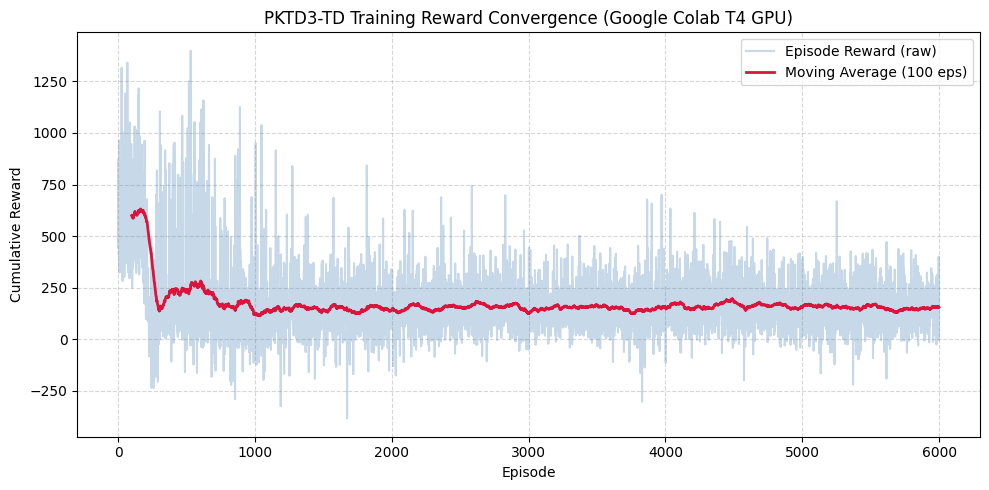

Reward curve saved to /content/uav_trajectory_rl/checkpoints/run4/training_reward_curve.png


In [6]:
# Step 5: Plot and visualize reward convergence
import os
import numpy as np
import matplotlib.pyplot as plt

rewards_file = os.path.join(local_checkpoint_dir, "episode_rewards.npy")
if os.path.exists(rewards_file):
    rewards = np.load(rewards_file)
    window = 100
    moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, color="steelblue", label="Episode Reward (raw)")
    plt.plot(range(window - 1, len(rewards)), moving_avg, color="crimson", linewidth=2, label=f"Moving Average ({window} eps)")
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.title("PKTD3-TD Training Reward Convergence (Google Colab T4 GPU)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plot_path = os.path.join(local_checkpoint_dir, "training_reward_curve.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Reward curve saved to {plot_path}")
else:
    print(f"Rewards file not found at {rewards_file}")

In [9]:
# Step 6: Commit and push all checkpoints and results to GitHub
!git config --global user.name "Krishna200608"
!git config --global user.email "krishnasikheriya001@gmail.com"

# Force-add checkpoints/run4 (overriding .gitignore for saved model artifacts)
!git add -f checkpoints/run4
!git status

!git commit -m "Add PKTD3-TD trained model checkpoints and reward history from Colab T4 run4"
!git push origin main
print("\nSuccessfully pushed checkpoints and reward logs to GitHub!")

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 35, done.
Counting objects: 100% (35/35), done.
Delta compression using up to 2 threads
Compressing objects: 100% (33/33), done.
Writing objects: 100% (33/33), 78.45 MiB | 10.18 MiB/s, done.
Total 33 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Krishna200608/uav_trajectory_rl.git
   b919345..0b597eb  main -> main

Successfully pushed checkpoints and reward logs to GitHub!
